# 4 — Making a Humanoid Walk

LIPM, ZMP, and an analytic gait · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/04-walking/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## Today the robot walks

No reinforcement learning. No training. No neural network.

Everything today comes from **one linear differential equation** and the
inverse kinematics you wrote in Week 3.

This is **Layer 4** — control and planning — doing the whole job on its
own. When we replace parts of it with learning in Week 8 onward, this is
what gets replaced, and you will know exactly what it was.

------------------------------------------------------------------------

## Why walking is hard

Standing still is a solved problem: put the centre of mass over the
feet.

Walking means **deliberately falling and catching yourself, twice a
second.**

- A humanoid is **underactuated** — no motor connects the robot to the
  ground, so you cannot simply command the body where to go
- The only way to push the body is **through a foot that is touching the
  floor**
- To move forward you must first become unbalanced
- The support region *changes shape* every step, and briefly is one
  small foot

------------------------------------------------------------------------

## The two ways to walk

**Static walking** keeps the centre of mass over the support foot at all
times. The robot can freeze at any instant and stay upright. It is slow,
and it looks like a robot from 1985.

**Dynamic walking** allows the centre of mass to leave the support
region, relying on momentum to carry it to the next foothold. It is
faster, more efficient, and how humans actually move — but freeze it
mid-step and it falls.

We build the dynamic kind. The tool that makes it tractable is a model
so simplified it seems like cheating.

------------------------------------------------------------------------

## Centre of pressure, and the ZMP

The floor can only **push**, never pull. All the little contact forces
under a foot sum to one resultant force, and the point where it acts is
the **centre of pressure (CoP)**.

The CoP **cannot leave the support polygon** — the convex hull of the
contact points. That is not a control law, it is geometry: there is no
floor outside the foot to push with.

In walking this point is usually called the **Zero Moment Point (ZMP)**.
The balance criterion for the whole semester:

> **ZMP inside the support polygon ⟹ the foot does not rotate about its
> edge.** Outside, the robot tips, and no ankle torque can stop it.

------------------------------------------------------------------------

## Our support polygon

Each G1 foot has four contact spheres. Their spread *is* the polygon:

In [1]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import numpy as np
import mujoco

model = soc4180.load_g1()

pts = [(model.geom_pos[g][0], model.geom_pos[g][1])
       for g in range(model.ngeom)
       if mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, model.geom_bodyid[g])
       == "left_ankle_roll_link"
       and model.geom_type[g] == mujoco.mjtGeom.mjGEOM_SPHERE]
pts = np.array(pts)
print("contact points in the foot frame (x, y):")
print(pts)
print(f"\nfoot length {np.ptp(pts[:,0]):.3f} m, width {np.ptp(pts[:,1]):.3f} m")

contact points in the foot frame (x, y):
[[-0.05   0.025]
 [-0.05  -0.025]
 [ 0.12   0.03 ]
 [ 0.12  -0.03 ]]

foot length 0.170 m, width 0.060 m

A single foot gives you about 17 cm by 6 cm to balance a 33 kg robot on.
That is the entire margin.

------------------------------------------------------------------------

## The polygon, drawn from the model

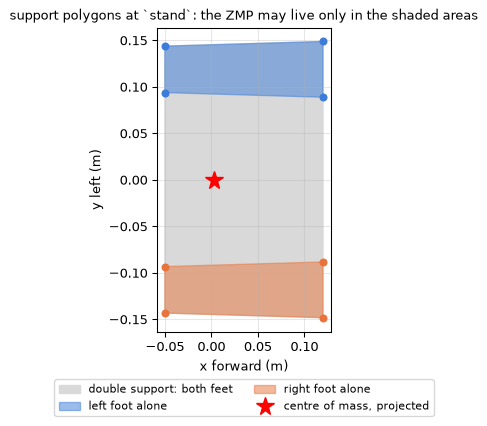

centre of mass projects to x = +0.003, y = +0.000

In [2]:
import matplotlib.pyplot as plt

data = soc4180.keyframe_data(model, "stand")
mujoco.mj_forward(model, data)
feet_xy = {}
for side, col in (("left", "#3b7dd8"), ("right", "#e8743b")):
    body = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, f"{side}_ankle_roll_link")
    feet_xy[side] = np.array([data.geom_xpos[g][:2] for g in range(model.ngeom)
                              if model.geom_bodyid[g] == body
                              and model.geom_type[g] == mujoco.mjtGeom.mjGEOM_SPHERE])

def hull(points):
    """Convex hull, counter-clockwise (Andrew's monotone chain)."""
    pts = sorted(map(tuple, points))
    def half(seq):
        h = []
        for p in seq:
            while len(h) >= 2:
                (ax_, ay_), (bx_, by_) = np.subtract(h[-1], h[-2]), np.subtract(p, h[-2])
                if ax_ * by_ - ay_ * bx_ > 0:      # left turn: keep it
                    break
                h.pop()
            h.append(p)
        return h
    lower, upper = half(pts), half(pts[::-1])
    return np.array(lower[:-1] + upper[:-1])

com = data.subtree_com[0][:2]
both = hull(np.vstack(list(feet_xy.values())))
fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.fill(both[:, 0], both[:, 1], color="0.85", label="double support: both feet")
for side, col in (("left", "#3b7dd8"), ("right", "#e8743b")):
    h = hull(feet_xy[side])
    ax.fill(h[:, 0], h[:, 1], color=col, alpha=0.5, label=f"{side} foot alone")
    ax.plot(feet_xy[side][:, 0], feet_xy[side][:, 1], "o", color=col, ms=5)
ax.plot(com[0], com[1], "r*", ms=14, label="centre of mass, projected")
ax.set_aspect("equal"); ax.set_xlabel("x forward (m)"); ax.set_ylabel("y left (m)")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2); ax.grid(alpha=0.3)
ax.set_title("support polygons at `stand`: the ZMP may live only in the shaded areas", fontsize=10)
fig.tight_layout(); plt.show()
print(f"centre of mass projects to x = {com[0]:+.3f}, y = {com[1]:+.3f}")

Standing on both feet the polygon is the big grey shape. Lift one foot
and it collapses to a single 17 cm by 6 cm patch — and the centre of
mass, the red star, has to be *above* it or the robot tips.

------------------------------------------------------------------------

## The Linear Inverted Pendulum Model

Replace the robot with a point mass on a massless leg, and impose one
assumption: **the centre of mass stays at constant height.**

That assumption removes the vertical dynamics and linearises everything:

$$\ddot{x} = \omega^2\,(x - p), \qquad \omega = \sqrt{g / z_c}$$

where $p$ is the ZMP. Read it as: **the mass accelerates away from the
ZMP**, and faster the further away it gets. Balancing is unstable, which
is why it needs constant attention.

$\omega$ is the only parameter, and $1/\omega$ is the natural timescale
of falling.

------------------------------------------------------------------------

## Where the equation comes from

Take moments about the ZMP. The floor pushes up through $p$; gravity
pulls down through the mass. Hold the height at $z_c$ and the vertical
acceleration is zero, so the floor force is exactly $mg$, and the moment
balance is the whole equation of motion:

$$m\,z_c\,\ddot{x} \;=\; m\,g\,(x - p)
\qquad\Longrightarrow\qquad
\ddot{x} = \frac{g}{z_c}\,(x - p) = \omega^2 (x - p)$$

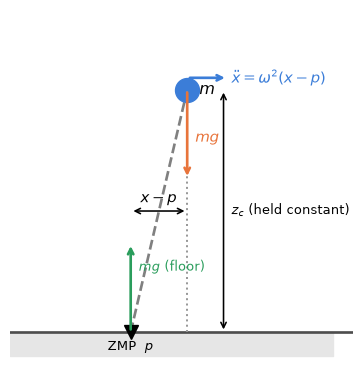

In [3]:
zc, xm, pz = 0.60, 0.14, 0.0
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.axhline(0, color="0.3", lw=2); ax.fill_between([-0.3, 0.5], -0.06, 0, color="0.9")
ax.plot([pz, xm], [0, zc], color="0.5", lw=2, ls="--")                       # massless leg
ax.plot(xm, zc, "o", ms=18, color="#3b7dd8"); ax.text(xm + 0.03, zc, "$m$", fontsize=12, va="center")
ax.plot(pz, 0, "kv", ms=10); ax.text(pz, -0.045, "ZMP  $p$", ha="center", fontsize=10)
ax.annotate("", xy=(xm, zc - 0.22), xytext=(xm, zc), arrowprops=dict(arrowstyle="->", lw=2, color="#e8743b"))
ax.text(xm + 0.02, zc - 0.13, "$mg$", color="#e8743b", fontsize=11)
ax.annotate("", xy=(pz, 0.22), xytext=(pz, 0), arrowprops=dict(arrowstyle="->", lw=2, color="#2a9d5c"))
ax.text(pz + 0.02, 0.15, "$mg$ (floor)", color="#2a9d5c", fontsize=10)
ax.plot([xm, xm], [0, zc], ":", color="0.6")
ax.annotate("", xy=(xm, 0.30), xytext=(pz, 0.30), arrowprops=dict(arrowstyle="<->", lw=1.2))
ax.text((pz + xm) / 2, 0.32, "$x - p$", ha="center", fontsize=11)
ax.annotate("", xy=(xm + 0.09, zc), xytext=(xm + 0.09, 0), arrowprops=dict(arrowstyle="<->", lw=1.2))
ax.text(xm + 0.11, zc / 2, "$z_c$ (held constant)", fontsize=10, va="center")
ax.annotate("", xy=(xm + 0.10, zc + 0.03), xytext=(xm, zc + 0.03),
            arrowprops=dict(arrowstyle="->", lw=2, color="#3b7dd8"))
ax.text(xm + 0.11, zc + 0.03, r"$\ddot{x} = \omega^2 (x-p)$", color="#3b7dd8", fontsize=11, va="center")
ax.set_xlim(-0.3, 0.55); ax.set_ylim(-0.08, 0.8); ax.set_aspect("equal"); ax.axis("off")
fig.tight_layout(); plt.show()

Every simplification is visible in the picture: one mass, a massless
leg, a constant height, and a single point of support.

------------------------------------------------------------------------

## Solving it exactly

The equation is linear with constant coefficients, so it has a
closed-form solution — no integration, no optimisation:

$$x(t) = p + (x_0 - p)\cosh(\omega t) + \frac{v_0}{\omega}\sinh(\omega t)$$

In [4]:
lipm = soc4180.LIPM(com_height=0.60)
print(f"omega   = {lipm.omega:.3f} rad/s")
print(f"1/omega = {1/lipm.omega:.3f} s   <- how long you have to react")

for t in (0.0, 0.1, 0.2, 0.4):
    x, v = lipm.evolve(x0=0.0, v0=0.0, zmp=0.05, t=t)
    print(f"  t={t:.1f}s  released 5 cm from the ZMP:  x={x:+.4f} m  v={v:+.4f} m/s")

omega   = 4.044 rad/s
1/omega = 0.247 s   <- how long you have to react
  t=0.0s  released 5 cm from the ZMP:  x=+0.0000 m  v=+0.0000 m/s
  t=0.1s  released 5 cm from the ZMP:  x=-0.0041 m  v=-0.0840 m/s
  t=0.2s  released 5 cm from the ZMP:  x=-0.0173 m  v=-0.1819 m/s
  t=0.4s  released 5 cm from the ZMP:  x=-0.0810 m  v=-0.4894 m/s

Released at rest, the mass runs away exponentially. `cosh` and `sinh`
*are* falling over, written down.

------------------------------------------------------------------------

## The trick: run it backwards

We do not want to know where the robot falls. We want to know **what
launch velocity puts it where we need it** at the end of the step.

That is a two-point boundary value problem, and because the model is
linear it also has a closed form:

$$v_0 = \omega\,\frac{x_T - p - (x_0 - p)\cosh(\omega T)}{\sinh(\omega T)}$$

In [5]:
T = 0.65
v0 = lipm.bvp_velocity(x0=-0.07, xT=+0.07, zmp=0.0, T=T)
xT, vT = lipm.evolve(-0.07, v0, 0.0, T)
print(f"required launch velocity : {v0:+.4f} m/s")
print(f"arrives at               : {xT:+.4f} m  (asked for +0.0700)")
print(f"with velocity            : {vT:+.4f} m/s")

required launch velocity : +0.3271 m/s
arrives at               : +0.0700 m  (asked for +0.0700)
with velocity            : +0.3271 m/s

**Each step is one boundary value problem.** Chain them — every step
starting where the last ended — and you have a gait.

------------------------------------------------------------------------

## The sideways problem

Forward motion is a straight line. Sideways is an oscillation, and it is
the part that makes walking *look* like walking.

Demand that each step be the mirror of the last, $(y, v) \to (-y, -v)$.
Working that through the step map forces $y_0 = 0$: **the centre of mass
is always on the midline at the moment support switches.**

In [6]:
w = 0.119                       # stance foot offset
vy = lipm.lateral_periodic_velocity(zmp_y=w, step_time=T)
sway = [lipm.evolve(0.0, vy, w, f*T)[0] for f in np.linspace(0, 1, 41)]
print(f"launch velocity toward the stance foot : {vy:+.4f} m/s")
print(f"maximum sway                           : {max(sway):.4f} m")
print(f"stance foot is at                      : {w:.4f} m")
print(f"returns to midline at t=T              : {sway[-1]:+.6f} m")

launch velocity toward the stance foot : +0.4164 m/s
maximum sway                           : 0.0594 m
stance foot is at                      : 0.1190 m
returns to midline at t=T              : +0.000000 m

The body sways **toward** the supporting foot, gravity turns it around,
and it arrives back at the centre exactly when the other foot is ready.
The sway is not decoration — it is what buys time to swing a leg.

------------------------------------------------------------------------

## Both directions, drawn

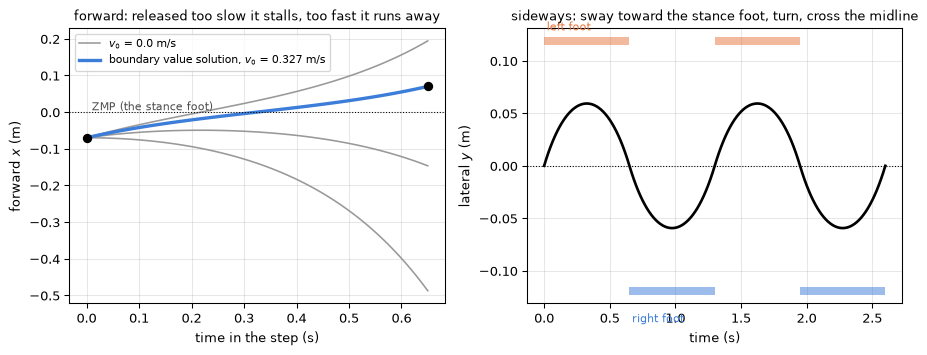

In [7]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.8))

tt = np.linspace(0, T, 60)
for v in (0.0, 0.2, 0.4):
    ax0.plot(tt, [lipm.evolve(-0.07, v, 0.0, t)[0] for t in tt], color="0.6", lw=1.2,
             label=f"$v_0$ = {v:.1f} m/s" if v == 0 else None)
v0 = lipm.bvp_velocity(-0.07, +0.07, 0.0, T)
ax0.plot(tt, [lipm.evolve(-0.07, v0, 0.0, t)[0] for t in tt], color="#3b7dd8", lw=2.5,
         label=f"boundary value solution, $v_0$ = {v0:.3f} m/s")
ax0.plot([0, T], [-0.07, 0.07], "ko"); ax0.axhline(0, color="k", lw=0.8, ls=":")
ax0.text(0.01, 0.005, "ZMP (the stance foot)", fontsize=8, color="0.3")
ax0.set_xlabel("time in the step (s)"); ax0.set_ylabel("forward $x$ (m)")
ax0.legend(fontsize=8, loc="upper left"); ax0.grid(alpha=0.3)
ax0.set_title("forward: released too slow it stalls, too fast it runs away", fontsize=10)

vy = lipm.lateral_periodic_velocity(zmp_y=w, step_time=T)
ys, ts, y, v = [], [], 0.0, vy
for k in range(4):
    zmp = w if k % 2 == 0 else -w
    for t in np.linspace(0, T, 40):
        ys.append(lipm.evolve(y, v, zmp, t)[0]); ts.append(k * T + t)
    y, v = lipm.evolve(y, v, zmp, T); v = v            # continue from where it ended
    ax1.hlines(zmp, k * T, (k + 1) * T, color="#e8743b" if zmp > 0 else "#3b7dd8", lw=6, alpha=0.5)
ax1.plot(ts, ys, color="k", lw=2, label="centre of mass $y$")
ax1.axhline(0, color="k", lw=0.8, ls=":")
ax1.set_xlabel("time (s)"); ax1.set_ylabel("lateral $y$ (m)"); ax1.grid(alpha=0.3)
ax1.text(0.02, w + 0.01, "left foot", fontsize=8, color="#e8743b")
ax1.text(T + 0.02, -w - 0.03, "right foot", fontsize=8, color="#3b7dd8")
ax1.set_title("sideways: sway toward the stance foot, turn, cross the midline", fontsize=10)
fig.tight_layout(); plt.show()

The left plot is $\cosh$ and $\sinh$ doing exactly what the equation
says: the mass accelerates *away* from the ZMP, and there is one launch
velocity that lands it where the next step needs it. The right plot
never reaches the foot it leans toward — gravity turns it back — and
crosses the midline exactly at each support exchange.

------------------------------------------------------------------------

## Planning the footsteps

In [8]:
params = soc4180.GaitParams()
print(f"step length {params.step_length} m, step time {params.step_time} s, "
      f"clearance {params.step_height} m")
print(f"double support {params.double_support*100:.0f}% at each end of the step\n")

for k, (support, support_xy, swing_from, swing_to) in enumerate(
        soc4180.footstep_plan(params)[:5]):
    print(f"  step {k}: stand on {support:5s} at x={support_xy[0]:+.2f}  "
          f"swing {swing_from[0]:+.2f} -> {swing_to[0]:+.2f}")

step length 0.14 m, step time 0.65 s, clearance 0.1 m
double support 20% at each end of the step

  step 0: stand on right at x=+0.00  swing +0.00 -> +0.07
  step 1: stand on left  at x=+0.07  swing +0.00 -> +0.14
  step 2: stand on right at x=+0.14  swing +0.07 -> +0.21
  step 3: stand on left  at x=+0.21  swing +0.14 -> +0.28
  step 4: stand on right at x=+0.28  swing +0.21 -> +0.35

The first step is a half stride, because both feet start level and a
full stride would over-reach.

------------------------------------------------------------------------

## Swinging the leg

The swing foot needs a path that **starts and ends at rest**. A foot
still moving when it lands will slip or trip, and a foot that leaves
abruptly drags.

- Horizontal: a cycloid-like blend, zero velocity at both ends
- Vertical: lift and lower, peaking at mid-swing
- **Double support**: for the first and last 20% of the step, *both*
  feet stay planted so weight can transfer

That double-support margin is not a detail. Without it the robot is on
one foot 100% of the time and falls within a few steps — you will test
this.

------------------------------------------------------------------------

## The plan and the swing, drawn

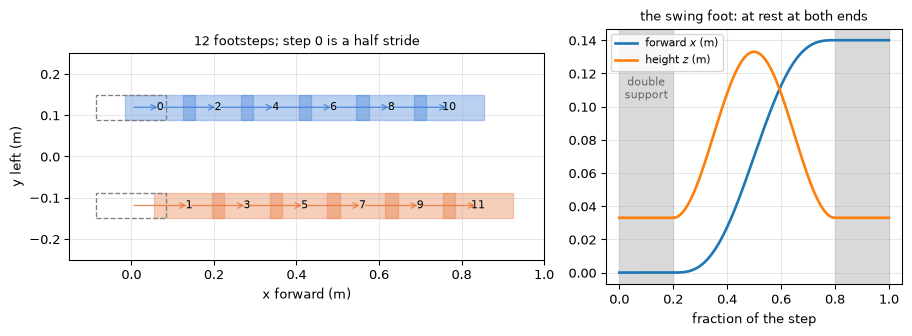

In [9]:
from soc4180.walking import _swing_xy, _swing_z

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
plan = soc4180.footstep_plan(params)
for k, (support, support_xy, swing_from, swing_to) in enumerate(plan):
    swing = "left" if support == "right" else "right"
    col = "#3b7dd8" if swing == "left" else "#e8743b"
    ax0.add_patch(plt.Rectangle((swing_to[0] - 0.085, swing_to[1] - 0.03), 0.17, 0.06,
                                color=col, alpha=0.35))
    ax0.text(swing_to[0], swing_to[1], str(k), ha="center", va="center", fontsize=8)
    ax0.annotate("", xy=swing_to, xytext=swing_from,
                 arrowprops=dict(arrowstyle="->", color=col, lw=1, alpha=0.8))
for side, y0 in (("left", +params.stance_width), ("right", -params.stance_width)):
    ax0.add_patch(plt.Rectangle((-0.085, y0 - 0.03), 0.17, 0.06, fill=False, ls="--", color="0.5"))
ax0.set_xlim(-0.15, 1.0); ax0.set_ylim(-0.25, 0.25); ax0.set_aspect("equal")
ax0.set_xlabel("x forward (m)"); ax0.set_ylabel("y left (m)")
ax0.set_title(f"{len(plan)} footsteps; step 0 is a half stride", fontsize=10); ax0.grid(alpha=0.3)

s = np.linspace(0, 1, 200)
ds = params.double_support
s_sw = np.clip((s - ds) / (1 - 2 * ds), 0, 1)
ax1.plot(s, [_swing_xy(0.0, params.step_length, v) for v in s_sw], lw=2, label="forward $x$ (m)")
ax1.plot(s, [_swing_z(params.step_height, params.foot_height, v) for v in s_sw], lw=2, label="height $z$ (m)")
ax1.axvspan(0, ds, color="0.85"); ax1.axvspan(1 - ds, 1, color="0.85")
ax1.text(ds / 2, 0.105, "double\nsupport", ha="center", fontsize=8, color="0.4")
ax1.set_xlabel("fraction of the step"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("the swing foot: at rest at both ends", fontsize=10)
fig.tight_layout(); plt.show()

Feet alternate, each landing one stride ahead of where the same foot
last stood. The swing curves have **zero slope at both ends** — the foot
leaves and lands without a jolt — and go nowhere at all in the grey
double-support bands.

------------------------------------------------------------------------

## Assembling the controller

Every control cycle, at 500 Hz:

1.  Which step are we in, and how far through it?
2.  **Where should the body be?** → the LIPM boundary value problem
3.  **Where should each foot be?** → planted, or on its swing path
4.  **What joint angles achieve that?** → inverse kinematics, both legs
5.  Send those angles to the position servos

Steps 2–3 are this week. Step 4 is Week 3’s work, reused unchanged. That
is the payoff of building the layers separately.

------------------------------------------------------------------------

## One trap: the singularity

The G1’s `stand` keyframe has **every leg joint at exactly zero** — a
perfectly straight leg. That is a kinematic singularity: the Jacobian
has no direction that shortens the leg, so IK cannot lower the body from
it, at all.

In [10]:
from soc4180 import kinematics as kin

data = soc4180.keyframe_data(model, "stand")
mujoco.mj_forward(model, data)
print("'stand' left-leg joint angles:", np.round(data.qpos[kin.leg_qpos_indices(model, "left")], 3))

controller = soc4180.WalkingController(model)
print("nominal crouch used instead   :",
      np.round(controller.nominal[kin.leg_qpos_indices(model, "left")], 3))

'stand' left-leg joint angles: [0. 0. 0. 0. 0. 0.]
nominal crouch used instead   : [-0.35  0.    0.    0.7  -0.35  0.  ]

Every gait therefore starts from a **crouch**. Humans do this too: you
do not walk with locked knees.

------------------------------------------------------------------------

## Watch it walk

In [11]:
controller = soc4180.WalkingController(model, soc4180.GaitParams(n_steps=12))
data = controller.initial_data()

frames = soc4180.render_rollout(
    model, data,
    duration=controller.total_time, fps=30, width=640, height=480,
    ctrl_fn=controller.ctrl_fn(),
    track="pelvis", distance=2.6, azimuth=135,
)
print(f"walked {data.qpos[0]:+.2f} m in {data.time:.1f} s "
      f"({data.qpos[0]/data.time:.2f} m/s), pelvis still at {data.qpos[2]:.2f} m")
soc4180.show_video(frames, fps=30)

walked +0.99 m in 8.8 s (0.11 m/s), pelvis still at 0.72 m

------------------------------------------------------------------------

## What you just watched

A 29-degree-of-freedom humanoid walking, driven by:

- one second-order linear ODE
- a closed-form solution to a boundary value problem, once per step
- a cycloid
- inverse kinematics

**No training. No data. No reward function.** Roughly two hundred lines.

Remember this when a walking policy takes 150 million simulation steps
to learn the same thing. Learning buys robustness, not the gait itself.

------------------------------------------------------------------------

## Now measure it

Belief is not evidence. Where did the ZMP actually go?

In [12]:
controller = soc4180.WalkingController(model, soc4180.GaitParams(n_steps=12))
data = controller.initial_data()

log = []
while data.time < controller.total_time:
    data.ctrl[:] = controller.control(data.time)
    mujoco.mj_step(model, data)
    zx, zy = controller.zmp(data)
    log.append((data.time, data.qpos[0], data.qpos[1], data.qpos[2], zx, zy))

log = np.array(log)
walking = log[log[:, 0] > controller.params.settle_time]
grounded = walking[~np.isnan(walking[:, 4])]

print(f"travelled     {log[-1,1]:+.3f} m")
print(f"pelvis height [{log[:,3].min():.3f}, {log[:,3].max():.3f}] m — never fell")
print(f"ZMP y range   [{grounded[:,5].min():+.3f}, {grounded[:,5].max():+.3f}] m")
print(f"stance feet at +-{controller.params.stance_width:.3f} m")

travelled     +0.989 m
pelvis height [0.693, 0.740] m — never fell
ZMP y range   [-0.233, +0.105] m
stance feet at +-0.119 m

------------------------------------------------------------------------

## The model is wrong, usefully

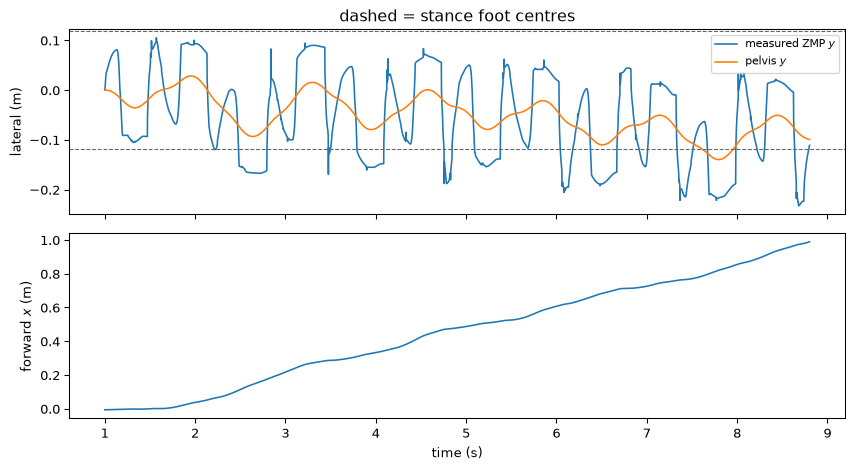

In [13]:
import matplotlib.pyplot as plt

w = controller.params.stance_width
fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

ax[0].plot(grounded[:, 0], grounded[:, 5], lw=1.2, label="measured ZMP $y$")
ax[0].plot(walking[:, 0], walking[:, 2], lw=1.2, label="pelvis $y$")
for s in (+w, -w):
    ax[0].axhline(s, ls="--", lw=0.8, color="0.4")
ax[0].set_ylabel("lateral (m)"); ax[0].legend(loc="upper right", fontsize=8)
ax[0].set_title("dashed = stance foot centres")

ax[1].plot(walking[:, 0], walking[:, 1], lw=1.2)
ax[1].set_ylabel("forward $x$ (m)"); ax[1].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

------------------------------------------------------------------------

## Where the ZMP actually went

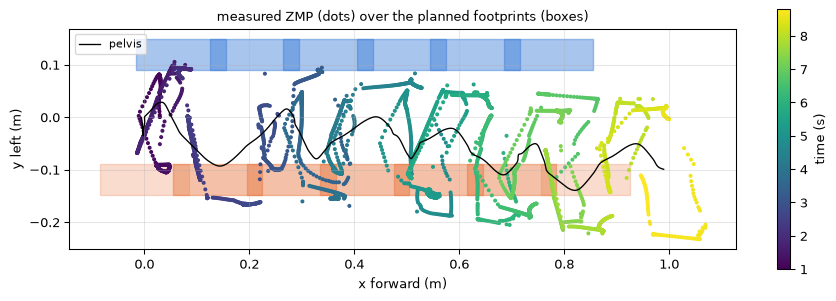

In [14]:
fig, ax = plt.subplots(figsize=(9.6, 3.2))
for k, (support, support_xy, swing_from, swing_to) in enumerate(controller.plan):
    for xy in (support_xy, swing_to):
        ax.add_patch(plt.Rectangle((xy[0] - 0.085, xy[1] - 0.03), 0.17, 0.06,
                                   color="#3b7dd8" if xy[1] > 0 else "#e8743b", alpha=0.25))
sc = ax.scatter(grounded[:, 4], grounded[:, 5], c=grounded[:, 0], s=4, cmap="viridis")
ax.plot(walking[:, 1], walking[:, 2], color="k", lw=1, label="pelvis")
plt.colorbar(sc, ax=ax, label="time (s)")
ax.set_aspect("equal"); ax.set_xlabel("x forward (m)"); ax.set_ylabel("y left (m)")
ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)
ax.set_title("measured ZMP (dots) over the planned footprints (boxes)", fontsize=10)
fig.tight_layout(); plt.show()

The dots should never leave a box. They do — by up to ten centimetres
sideways at every support exchange. That is not a measurement error; it
is the list on the next slide.

------------------------------------------------------------------------

## Where the LIPM breaks

The measured ZMP swings **wider than the feet**. The theory says that
cannot happen — and the theory is right; the assumptions are what
failed:

| LIPM assumes                     | The G1 actually                          |
|------------------------------------|------------------------------------|
| A point mass                     | Has a swinging leg with real momentum    |
| Constant CoM height              | Bobs as the stance leg compresses        |
| Massless legs                    | Carries ~30% of its mass below the hips  |
| Instant support exchange         | Rolls weight across a finite foot        |
| Perfectly rigid position control | Uses servos of finite stiffness that sag |

It walks anyway. **A model does not have to be true to be useful — it
has to be wrong in ways that do not matter yet.** Week 13 is where they
start to matter.

------------------------------------------------------------------------

## The honest limitations

This controller is **open loop**. It never looks at the IMU, never
measures where the body actually is, and never corrects.

Consequences you can see in the data:

- it **drifts sideways** over many steps, with nothing to pull it back
- it cannot recover from a push, at all
- it walks on flat ground only — one unexpected step and it is over
- the gait is fixed at design time; asking for a different speed means
  re-deriving

Every one of these is a reason the field moved to learned policies.
**Not because the mathematics is wrong** — you just watched it work —
but because hand-derived control is brittle outside the conditions it
was derived for.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/04-walking/lab_walk.py
```

The walker, live and in real time. Keys `1`–`5` pick a gait from the
`GAITS` list at the top of the file; `G` switches to Moon gravity and
`F` to ice *without telling the controller*; ctrl-drag pushes the robot.

On the floor: the **footstep plan** as grey boxes, the **commanded
centre of mass** for the current step as white dots, the **pelvis** as a
red sphere and the **measured ZMP** as a yellow one. Blue dots are
*your* LIPM: `predict_com(x0, v0, zmp, t, omega)` is empty until you
write the cosh/sinh solution, and right means blue inside white on every
step.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | write `predict_com` | blue dots inside the white ones; flip the sinh sign and they run backwards |
| 2 | press `2` (no double support) | count the steps before the fall, and say which way |
| 3 | press `3`, then shrink `step_time` in `GAITS` | find the failure point and compare it to $1/\omega$ |
| 4 | press `G` | the prediction from $\omega=\sqrt{g/z_c}$ made before looking |
| 5 | ctrl-drag while walking | it never reacts: name what it would need to know |
| 6 | add a gait that walks further | `ENTER` prints the distance that proves it |

------------------------------------------------------------------------

## Exercises

Break it deliberately, and record what fails and why.

1.  **Remove double support.** Set `double_support=0.0`. How many steps
    before it falls? Which direction, and why that direction?
2.  **Rush it.** Reduce `step_time` toward 0.35 s. Find the value where
    it fails. Compare it to $1/\omega$ — is the failure point near the
    model’s own timescale?
3.  **Overstride.** Increase `step_length`. Where does it break, and is
    it the swing leg reaching its limit or the balance failing?
4.  **Ice.** Set the floor friction to 0.2
    (`model.geom_friction[0, 0] = 0.2`). The ZMP argument assumes no
    slipping — what actually happens?
5.  **Moon.** Set gravity to $-1.62\ \mathrm{m/s^2}$ **without**
    changing the controller. Predict the failure from
    $\omega = \sqrt{g/z_c}$ before running it.
6.  **Instrument it.** Plot the ZMP against the *support polygon of the
    current stance foot* rather than a fixed line, and measure what
    fraction of the walk is genuinely inside.

------------------------------------------------------------------------

## Next week

**05 — actuation and PD control.** Today we assumed the joints simply go
where they are told. They do not: they are position servos with finite
gain, and that is why the pelvis sagged below its commanded height all
through this lecture.

We tune those gains, measure tracking error against torque saturation,
and then build a gait with **no model at all** — a central pattern
generator — to compare against today’s.